<a href="https://www.kaggle.com/code/mohammadtamer/gender-classification?scriptVersionId=317510596" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/elakiricoder/gender-classification-dataset/gender_classification_v7.csv


# Reading Data

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../input/datasets/elakiricoder/gender-classification-dataset/gender_classification_v7.csv')
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


# Data Info

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  5001 non-null   int64  
 1   forehead_width_cm          5001 non-null   float64
 2   forehead_height_cm         5001 non-null   float64
 3   nose_wide                  5001 non-null   int64  
 4   nose_long                  5001 non-null   int64  
 5   lips_thin                  5001 non-null   int64  
 6   distance_nose_to_lip_long  5001 non-null   int64  
 7   gender                     5001 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 312.7+ KB


# Distribution of Data

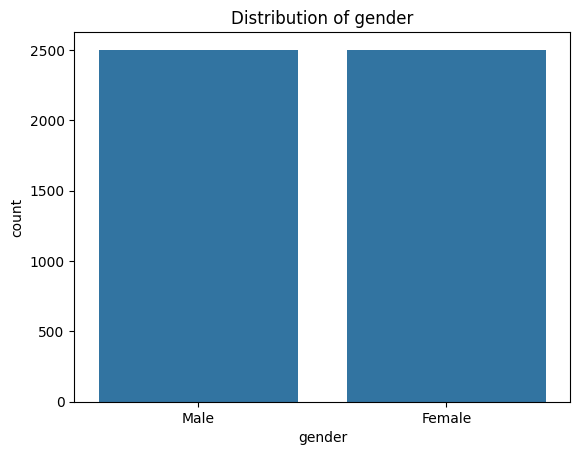

In [4]:
sns.countplot(data=df, x='gender')
plt.title('Distribution of gender')
plt.show()

# Finding missing data

In [5]:
total = df.isnull().sum().sort_values(ascending = False)
percent = (df.isnull().sum() / df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis = 1, keys = ['Total_NaN', 'Percent_Nan'])
missing_data.head(14)

,Total_NaN,Percent_Nan
long_hair,0,0.0
forehead_width_cm,0,0.0
forehead_height_cm,0,0.0
nose_wide,0,0.0
nose_long,0,0.0
lips_thin,0,0.0
distance_nose_to_lip_long,0,0.0
gender,0,0.0


# Correlation Matrix

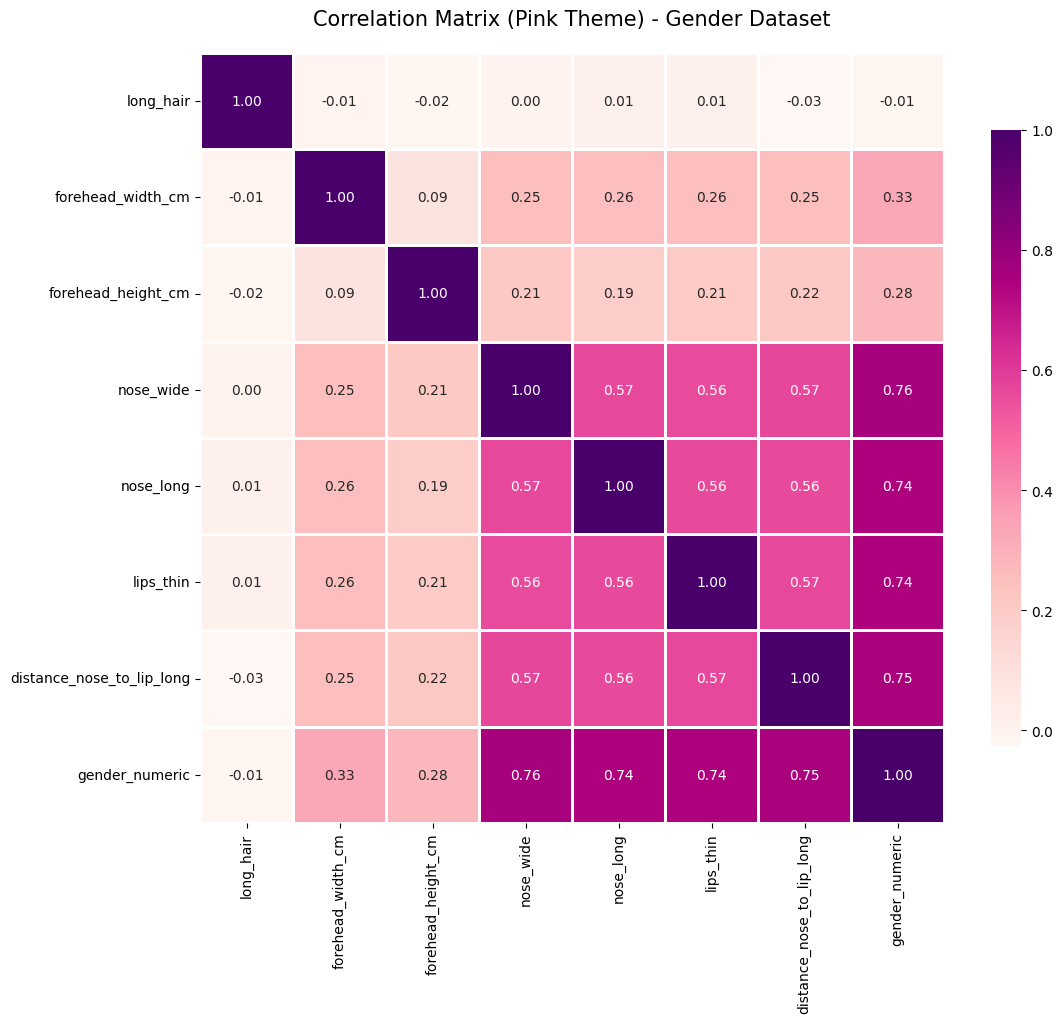

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

df['gender_numeric'] = LabelEncoder().fit_transform(df['gender'])

corr_matrix = df.drop('gender', axis=1).corr()

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='RdPu', 
            fmt='.2f', 
            linewidths=1, 
            linecolor='white',
            cbar_kws={"shrink": .8})

plt.title('Correlation Matrix (Pink Theme) - Gender Dataset', fontsize=15, pad=20)
plt.show()

# Modeling 

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df.drop(['gender', 'gender_numeric'], axis=1)
y = df['gender_numeric']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    p = model.predict(X_test)
    print(f" {name} Accuracy: {accuracy_score(y_test, p):.4f}")

 SVM Accuracy: 0.9630
 Decision Tree Accuracy: 0.9530
 Random Forest Accuracy: 0.9570


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

X = df.drop(['gender', 'gender_numeric'], axis=1)
y = df['gender_numeric']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

models = {
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

print(" Results with Scaled Data")
for name, model in models.items():
    model.fit(X_train, y_train)
    p = model.predict(X_test)
    print(f"{name} Accuracy: {accuracy_score(y_test, p):.4f}")

 Results with Scaled Data
SVM Accuracy: 0.9670
Decision Tree Accuracy: 0.9520
Random Forest Accuracy: 0.9620


# Confusion Matrix for SVM , Decision Tree and Random Forest


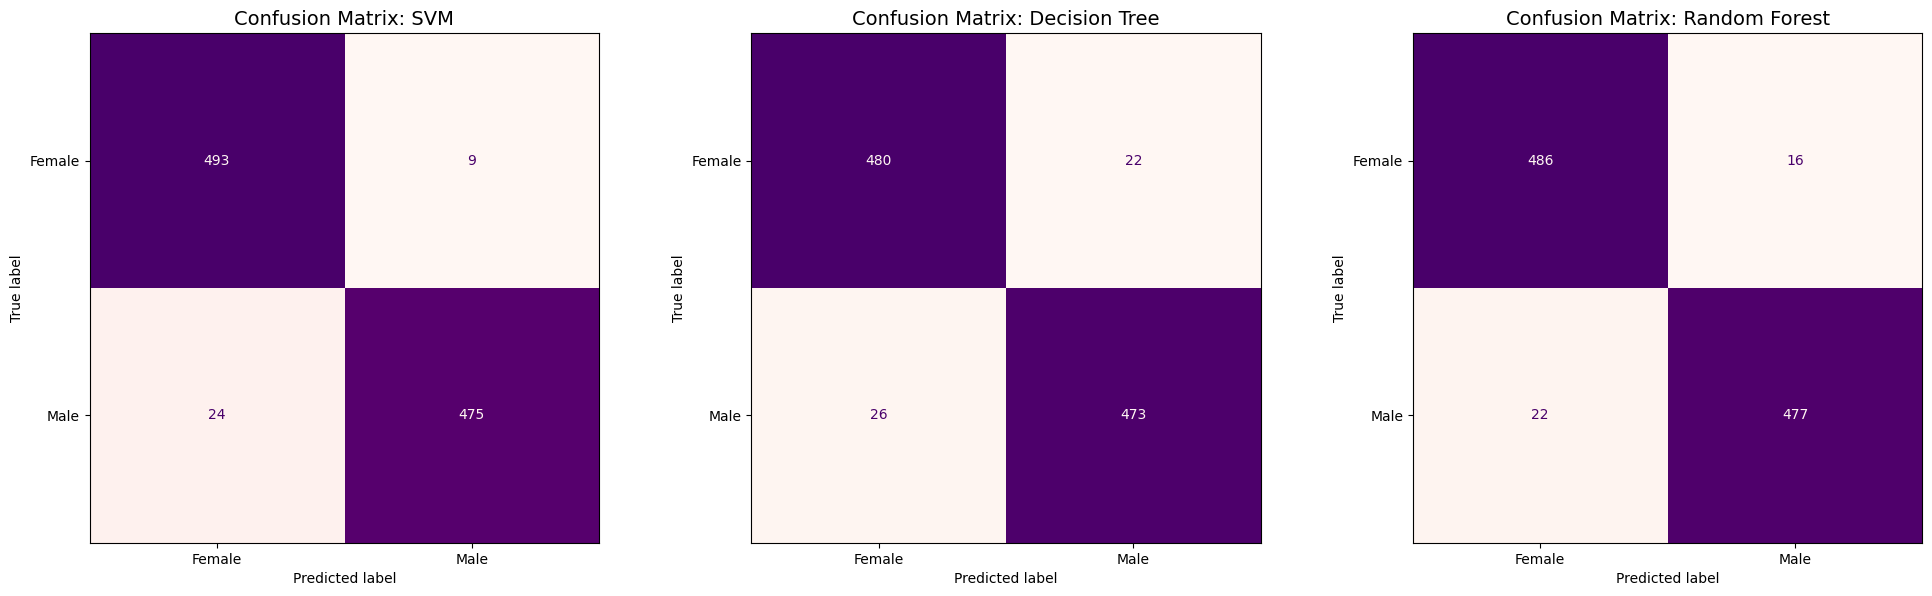

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

model_names = list(models.keys())

for i, name in enumerate(model_names):
    model = models[name]
    
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Female', 'Male'])
    disp.plot(ax=axes[i], cmap='RdPu', colorbar=False)
    
    axes[i].set_title(f'Confusion Matrix: {name}', fontsize=14)

plt.tight_layout()
plt.show()

# ROC Curve Comparison

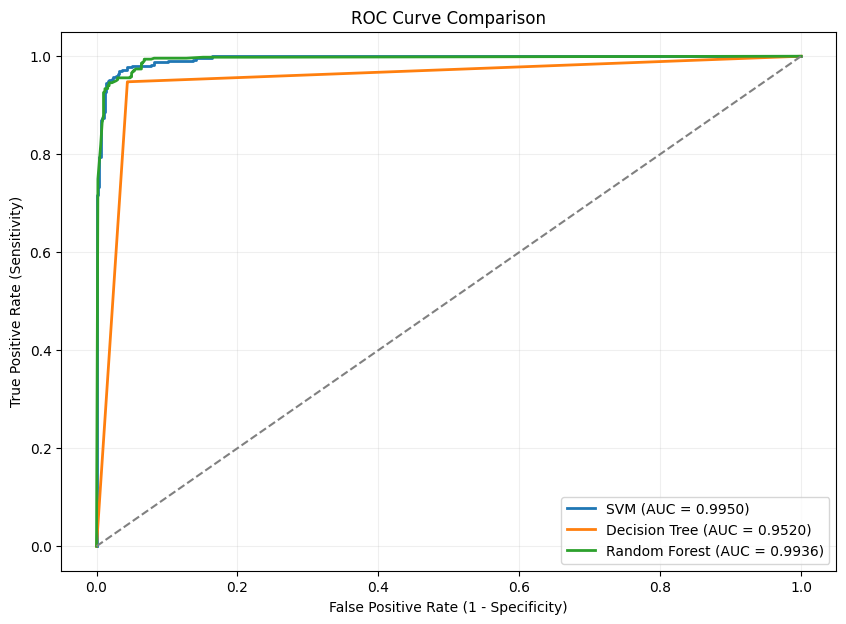

In [10]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))

for name, model in models.items():
    if name == "SVM":
        y_score = model.decision_function(X_test)
    else:
        y_score = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()
plt.show()

# Model Performance Metrics

In [11]:
from sklearn.metrics import f1_score, mean_absolute_error, classification_report
import pandas as pd

metrics_list = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    metrics_list.append({
        'Model': name,
        'F1-Score': f1,
        'MAE': mae
    })

results_df = pd.DataFrame(metrics_list)
print("--- Model Performance Metrics ---")
print(results_df.to_string(index=False))

print("\n--- Detailed Report for SVM ---")
print(classification_report(y_test, models['SVM'].predict(X_test), target_names=['Female', 'Male']))

--- Model Performance Metrics ---
        Model  F1-Score      MAE
          SVM  0.966429 0.032967
Decision Tree  0.951710 0.047952
Random Forest  0.961694 0.037962

--- Detailed Report for SVM ---
              precision    recall  f1-score   support

      Female       0.95      0.98      0.97       502
        Male       0.98      0.95      0.97       499

    accuracy                           0.97      1001
   macro avg       0.97      0.97      0.97      1001
weighted avg       0.97      0.97      0.97      1001



# MAE Comparison

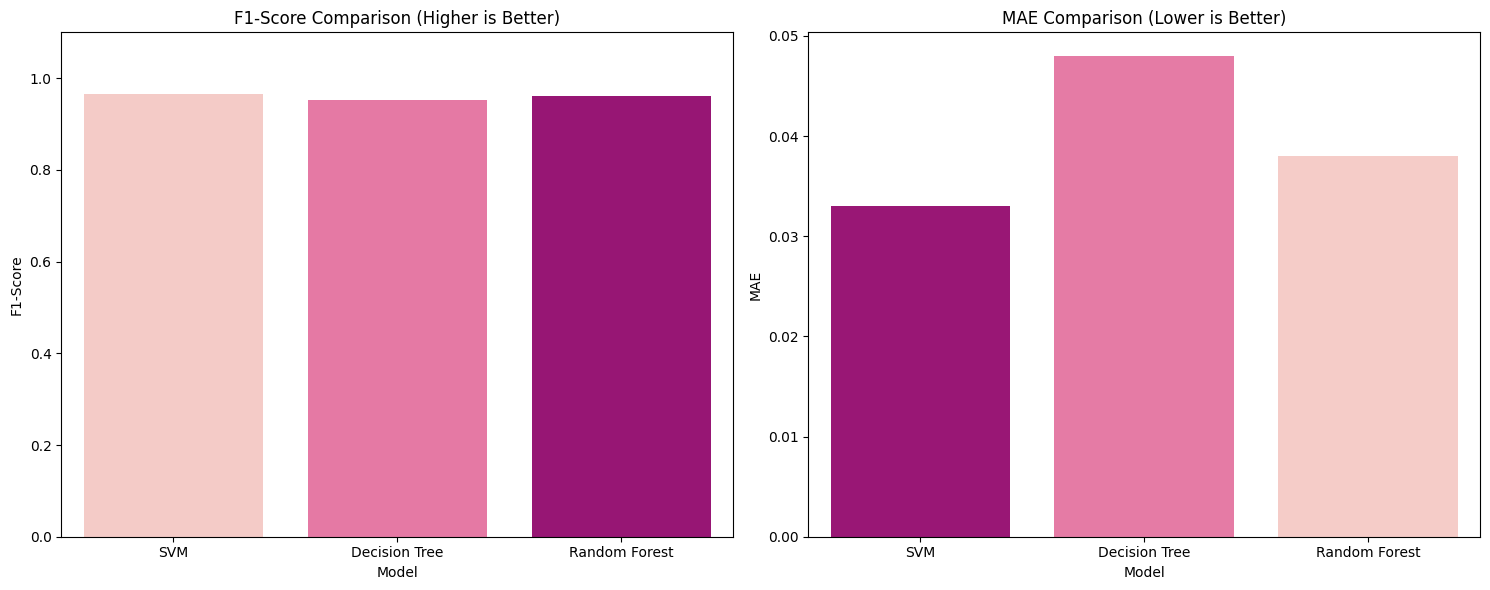

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=results_df, x='Model', y='F1-Score', hue='Model', ax=ax[0], palette='RdPu', legend=False)
ax[0].set_title('F1-Score Comparison (Higher is Better)')
ax[0].set_ylim(0, 1.1)

sns.barplot(data=results_df, x='Model', y='MAE', hue='Model', ax=ax[1], palette='RdPu_r', legend=False)
ax[1].set_title('MAE Comparison (Lower is Better)')

plt.tight_layout()
plt.show()

# Applying OOB

 Out-of-Bag (OOB) Score: 0.9725


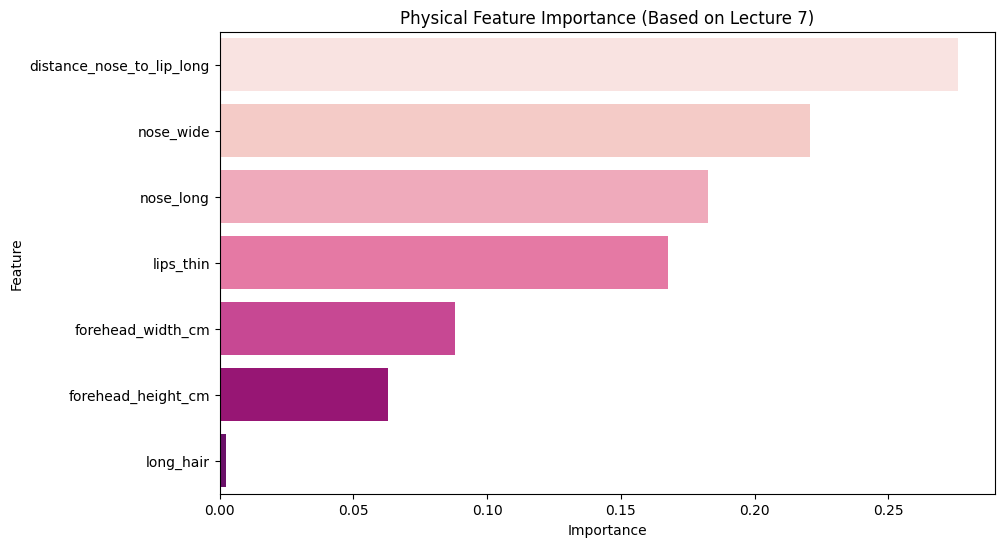

In [13]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

rnd_clf = RandomForestClassifier(
    n_estimators=500, 
    oob_score=True,     
    n_jobs=-1, 
    random_state=42
)
rnd_clf.fit(X_train, y_train)

print(f" Out-of-Bag (OOB) Score: {rnd_clf.oob_score_:.4f}") 

def plot_feature_importance(importance, feature_names):
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    fi_df = fi_df.sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=fi_df, x='Importance', y='Feature', hue='Feature', palette='RdPu', legend=False)
    plt.title('Physical Feature Importance (Based on Lecture 7)')
    plt.show()

plot_feature_importance(rnd_clf.feature_importances_, X.columns)

# Final Model Comparison & Evaluation

In [14]:
from sklearn.tree import DecisionTreeClassifier

X_final = df.drop(['gender', 'gender_numeric', 'long_hair'], axis=1)
y_final = df['gender_numeric']
X_final_scaled = scaler.fit_transform(X_final)
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_final_scaled, y_final, test_size=0.2, random_state=42)

final_models = {
    "Final SVM": SVC(probability=True),
    "Final Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Final Random Forest": RandomForestClassifier(n_estimators=500, oob_score=True, random_state=42)
}

print(f"{'Model':<20} | {'Accuracy':<10}")
print("-" * 35)

for name, model in final_models.items():
    model.fit(X_train_f, y_train_f)
    acc = model.score(X_test_f, y_test_f)
    print(f"{name:<20} | {acc:.4f}")
    if "Random Forest" in name:
        print(f"RF OOB Score: {model.oob_score_:.4f}")

Model                | Accuracy  
-----------------------------------
Final SVM            | 0.9670
Final Decision Tree  | 0.9590
Final Random Forest  | 0.9610
RF OOB Score: 0.9718
